<a href="https://colab.research.google.com/github/alok-raj-357/Electric-Vehicle-EV-Market-Analysis-EDA-/blob/main/IBMProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⏳ Downloading EV dataset from Kaggle...


100%|██████████| 4.77M/4.77M [00:00<00:00, 106MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/rajkumarpandey02/electric-vehicle-population-data/versions/1

✅ Dataset Loaded Successfully!
Data Shape: 135038 rows, 17 columns



/tmp/ipykernel_3369/2500335382.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette='Blues_r')


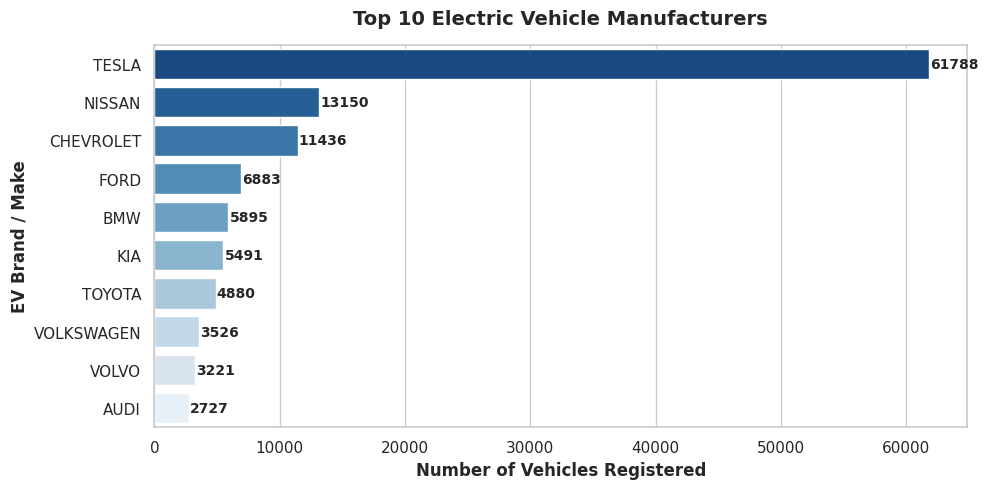

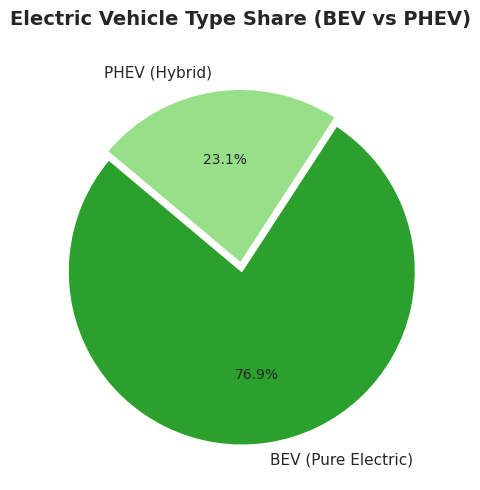

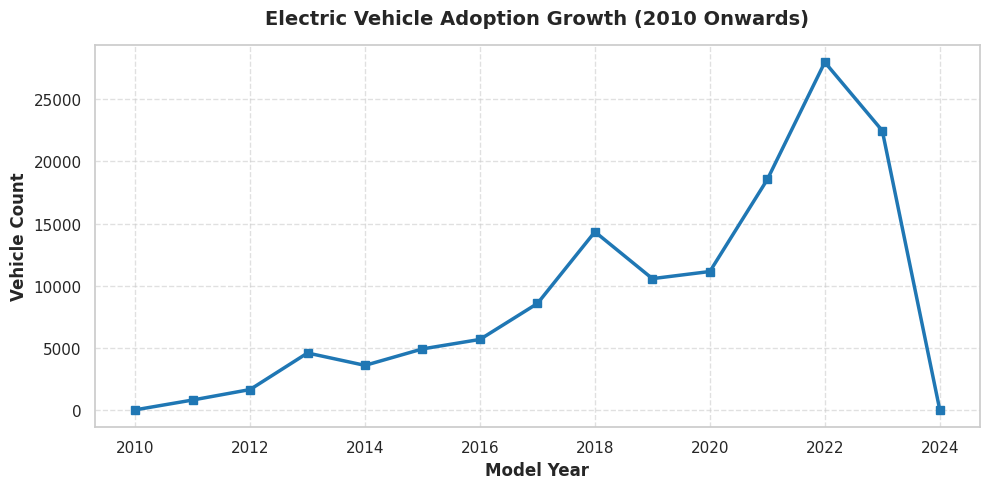

/tmp/ipykernel_3369/2500335382.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette='crest')


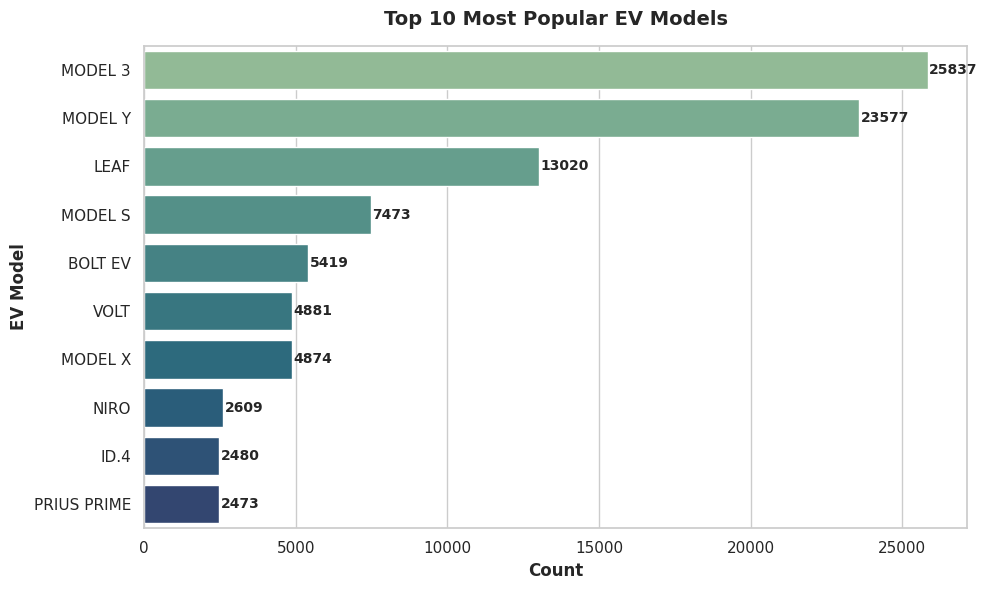

📌 KEY FINDINGS SUMMARY FOR PRESENTATION
• Total Vehicles Analyzed: 135000
• Top EV Brand: TESLA with 61788 registered vehicles.
• Most Popular Vehicle Type: Battery Electric Vehicle (BEV)
• Top Model: MODEL 3


In [3]:
# =========================================================
# Project: Electric Vehicle (EV) Market Analysis (EDA)
# Course Showcase: Data Visualization with Python
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Seaborn Global Theme Setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------
# STEP 1: Automatic Dataset Download & Load (via Kagglehub)
# ---------------------------------------------------------
print("⏳ Downloading EV dataset from Kaggle...")
# Download EV Population Dataset
path = kagglehub.dataset_download("rajkumarpandey02/electric-vehicle-population-data")
print(f"✅ Dataset downloaded to: {path}\n")

# Locate CSV file path and load into Pandas DataFrame
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_file_path = os.path.join(path, csv_file)
df = pd.read_csv(csv_file_path)

print("✅ Dataset Loaded Successfully!")
print(f"Data Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# ---------------------------------------------------------
# STEP 2: Data Cleaning & Filtering
# ---------------------------------------------------------
# Filter missing essential values and limit to recent model years
df_clean = df.dropna(subset=['Make', 'Electric Vehicle Type', 'Model Year'])
df_clean = df_clean[df_clean['Model Year'] >= 2010]

# ---------------------------------------------------------
# STEP 3: Data Visualizations (4 Key Insights)
# ---------------------------------------------------------

# 1. Top 10 EV Brands / Manufacturers
plt.figure(figsize=(10, 5))
top_makes = df_clean['Make'].value_counts().head(10)

sns.barplot(x=top_makes.values, y=top_makes.index, palette='Blues_r')
plt.title('Top 10 Electric Vehicle Manufacturers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Vehicles Registered', fontweight='bold')
plt.ylabel('EV Brand / Make', fontweight='bold')

for index, value in enumerate(top_makes.values):
    plt.text(value + 100, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 2. BEV (Battery Electric) vs PHEV (Plug-in Hybrid)
plt.figure(figsize=(7, 5))
ev_types = df_clean['Electric Vehicle Type'].value_counts()

plt.pie(ev_types.values, labels=['BEV (Pure Electric)', 'PHEV (Hybrid)'],
        autopct='%1.1f%%', startangle=140, colors=['#2ca02c', '#98df8a'], explode=(0.05, 0))
plt.title('Electric Vehicle Type Share (BEV vs PHEV)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# 3. EV Adoption Growth Over Years
plt.figure(figsize=(10, 5))
yearly_ev = df_clean['Model Year'].value_counts().sort_index()

plt.plot(yearly_ev.index, yearly_ev.values, marker='s', color='#1f77b4', linewidth=2.5)
plt.title('Electric Vehicle Adoption Growth (2010 Onwards)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Year', fontweight='bold')
plt.ylabel('Vehicle Count', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# 4. Top 10 Popular EV Models
plt.figure(figsize=(10, 6))
top_models = df_clean['Model'].value_counts().head(10)

sns.barplot(x=top_models.values, y=top_models.index, palette='crest')
plt.title('Top 10 Most Popular EV Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Count', fontweight='bold')
plt.ylabel('EV Model', fontweight='bold')

for index, value in enumerate(top_models.values):
    plt.text(value + 50, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# STEP 4: Key Insights Summary Print (For Presentation)
# ---------------------------------------------------------
print("="*60)
print("📌 KEY FINDINGS SUMMARY FOR PRESENTATION")
print("="*60)
print(f"• Total Vehicles Analyzed: {len(df_clean)}")
print(f"• Top EV Brand: {top_makes.index[0]} with {top_makes.values[0]} registered vehicles.")
print(f"• Most Popular Vehicle Type: {ev_types.index[0]}")
print(f"• Top Model: {top_models.index[0]}")
print("="*60)